### VAE training for human public data

Dataset: https://data.bris.ac.uk/data/dataset/21h9f9e30v9cl2fapjggz4q1x7

V2: 2026/06/12     

In [1]:
import json
import os
from pathlib import Path
from math import sqrt
import xarray as xr
import pandas as pd
import numpy as np
from collections import defaultdict
from umap import UMAP
import pickle


import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import mode
import hdbscan
import seaborn as sns

import cv2

import gc
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args


#### Prepare training data

In [2]:
# ── point to your REMAP data folder ───────────────────────────────────────
data_root = Path("./human_data")   # adjust this path

csv_files = sorted(data_root.rglob("keypoints.csv"))
print(f"Found {len(csv_files)} CSV files")

Found 1749 CSV files


In [3]:
sequences  = []
labels     = []
clip_names = []

for csv_path in csv_files:
    folder_name = csv_path.parent.parent.name
    if '_PD_' in folder_name:
        label = 'PD'
    elif '_C_' in folder_name:
        label = 'C'
    else:
        print(f"  WARNING: could not determine label for {folder_name}, skipping")
        continue

    df  = pd.read_csv(csv_path, header=None)
    arr = df.values.astype(np.float32)
    T   = arr.shape[0]
    seq = arr.reshape(T, 17, 2)

    sequences.append(seq)
    labels.append(label)
    clip_names.append(folder_name)

pd_count = labels.count('PD')
c_count  = labels.count('C')
print(f"\nLoaded {len(sequences)} clips: {pd_count} PD, {c_count} Control")
print(f"Clip lengths — min: {min(len(s) for s in sequences)}, "
      f"max: {max(len(s) for s in sequences)}, "
      f"mean: {np.mean([len(s) for s in sequences]):.1f}")

KEYPOINT_NAMES_HUMAN = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]

SKELETON_HUMAN = [
    (0,1),(0,2),(1,3),(2,4),
    (0,5),(0,6),(5,6),
    (5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]


Loaded 1749 clips: 963 PD, 786 Control
Clip lengths — min: 45, max: 294, mean: 70.4


In [4]:
sts_clips     = [n for n in clip_names if 'STS' in str(csv_files[clip_names.index(n)])]
turning_clips = [n for n in clip_names if 'Turning' in str(csv_files[clip_names.index(n)])]

print(f"STS clips:     {len(sts_clips)}")
print(f"Turning clips: {len(turning_clips)}")

# check PD/C split for each
sts_pd  = sum(1 for n in sts_clips if '_PD_' in n)
sts_c   = sum(1 for n in sts_clips if '_C_' in n)
turn_pd = sum(1 for n in turning_clips if '_PD_' in n)
turn_c  = sum(1 for n in turning_clips if '_C_' in n)

print(f"\nSTS:     {sts_pd} PD, {sts_c} Control")
print(f"Turning: {turn_pd} PD, {turn_c} Control")

STS clips:     0
Turning clips: 1749

STS:     0 PD, 0 Control
Turning: 963 PD, 786 Control


In [5]:
def preprocess_human(raw_sequence):
    """
    raw_sequence: (T, 17, 2)
    returns:      (T, 17, 8)
    """
    left_hip  = raw_sequence[:, 11, :]
    right_hip = raw_sequence[:, 12, :]
    center    = (left_hip + right_hip) / 2.0

    center_diff = np.diff(center, axis=0)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)
    speed       = np.linalg.norm(center_diff, axis=-1)
    speed       = np.tile(speed[:, None, None], (1, 17, 1))

    centered = raw_sequence - center[:, np.newaxis, :]

    nose  = centered[:, 0, :]
    angle = np.arctan2(nose[:, 1], nose[:, 0])

    cos_a   = np.cos(-angle)
    sin_a   = np.sin(-angle)
    x       = centered[:, :, 0]
    y       = centered[:, :, 1]
    x_rot   = x * cos_a[:, None] - y * sin_a[:, None]
    y_rot   = x * sin_a[:, None] + y * cos_a[:, None]
    aligned = np.stack([x_rot, y_rot], axis=-1)

    vel = np.diff(aligned, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)

    ang_vel = np.diff(angle, axis=0)
    ang_vel = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel = np.tile(ang_vel[:, None, None], (1, 17, 1))

    sin_h = np.tile(np.sin(angle)[:, None, None], (1, 17, 1))
    cos_h = np.tile(np.cos(angle)[:, None, None], (1, 17, 1))

    return np.concatenate([aligned, vel, ang_vel, speed,
                           sin_h, cos_h], axis=-1)   # (T, 17, 8)

In [6]:
all_processed          = []
group_labels_per_frame = []
clip_frame_ranges      = []
cursor = 0

for seq, label in zip(sequences, labels):
    processed = preprocess_human(seq)
    processed[0, :, 2:] = 0.0   # zero boundary frame
    all_processed.append(processed)
    group_labels_per_frame.extend([1 if label == 'PD' else 0] * len(processed))
    clip_frame_ranges.append((cursor, cursor + len(processed)))
    cursor += len(processed)

raw_processed    = np.concatenate(all_processed, axis=0)
group_labels_arr = np.array(group_labels_per_frame)

print(f"Total frames: {raw_processed.shape[0]}")
print(f"Shape: {raw_processed.shape}")
print(f"PD frames: {(group_labels_arr==1).sum()}, "
      f"Control frames: {(group_labels_arr==0).sum()}")

Total frames: 123057
Shape: (123057, 17, 8)
PD frames: 72830, Control frames: 50227


In [7]:
n_frames, n_joints, n_coords = raw_processed.shape
da_scaled = np.zeros_like(raw_processed)
scalers   = []

for j in range(n_joints):
    joint_scalers = []
    for c in range(n_coords):
        channel = raw_processed[:, j, c].reshape(-1, 1)
        scaler  = StandardScaler()
        normed  = scaler.fit_transform(channel)
        normed  = np.clip(normed, -5.0, 5.0)
        std     = normed.std()
        if std > 1e-8:
            normed = normed / std
        normed  = np.clip(normed, -5.0, 5.0)
        da_scaled[:, j, c] = normed.squeeze()
        joint_scalers.append(scaler)
    scalers.append(joint_scalers)

raw_processed = da_scaled
print(f"Scaled shape: {raw_processed.shape}")

Scaled shape: (123057, 17, 8)


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

#### Classes and functions for modeling

In [9]:
# ============================================================
# MODEL
# ============================================================

class HierarchicalRAE(nn.Module):
    def __init__(self,
                 joint_dim,
                 joint_embed=32,
                 pose_embed=128,
                 hidden_dim=256,
                 latent_dim=64,
                 num_joints=17):
        super().__init__()
        self.num_joints = num_joints

        # --- Encoder ---
        self.joint_encoder = nn.Sequential(
            nn.Linear(joint_dim, joint_embed),
            nn.Tanh(),
            nn.Linear(joint_embed, joint_embed)
        )
        self.pose_encoder = nn.Sequential(
            nn.Linear(num_joints * joint_embed, pose_embed),
            nn.Tanh()
        )
        self.encoder_rnn = nn.LSTM(pose_embed, hidden_dim, batch_first=True)
        self.fc_latent    = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder ---
        self.fc_decode_h  = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode_c  = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn  = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_proj = nn.Linear(hidden_dim, pose_embed)
        self.pose_decoder = nn.Sequential(
            nn.Linear(pose_embed, num_joints * joint_embed),
            nn.Tanh()
        )
        self.joint_decoder = nn.Linear(joint_embed, joint_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_decode_h.weight, gain=2.0)
        nn.init.xavier_uniform_(self.fc_decode_c.weight, gain=2.0)
        nn.init.constant_(self.fc_decode_h.bias, 0.0)
        nn.init.constant_(self.fc_decode_c.bias, 0.0)
        nn.init.xavier_uniform_(self.fc_latent.weight, gain=2.0)
        nn.init.constant_(self.fc_latent.bias, 0.0)

        for name, param in self.decoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param, gain=2.0)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param, gain=2.0)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for name, param in self.encoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for module in [self.joint_encoder, self.pose_encoder,
                       self.pose_decoder, self.joint_decoder,
                       self.decoder_proj]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight)
                        nn.init.zeros_(layer.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def encode(self, x, lengths=None):
        from torch.nn.utils.rnn import pack_padded_sequence
        B, T, J, C = x.shape

        x_flat = x.view(B * T * J, C)
        x_flat = self.joint_encoder(x_flat)
        x_enc  = x_flat.view(B, T, J, -1)
        x_enc  = x_enc.view(B, T, -1)
        x_enc  = self.pose_encoder(x_enc)

        if lengths is not None:
            packed = pack_padded_sequence(
                x_enc, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            _, (h, _) = self.encoder_rnn(packed)
        else:
            _, (h, _) = self.encoder_rnn(x_enc)

        z = self.fc_latent(h[-1])
        return z

    def decode(self, z, T):
        B   = z.shape[0]
        h   = self.fc_decode_h(z).unsqueeze(0)
        c   = self.fc_decode_c(z).unsqueeze(0)
        inp = z.unsqueeze(1).repeat(1, T, 1)
        dec, _ = self.decoder_rnn(inp, (h, c))
        dec    = self.decoder_proj(dec)
        return dec

    def forward(self, x, lengths=None):
        B, T, J, C = x.shape
        z   = self.encode(x, lengths)
        dec = self.decode(z, T)
        dec = self.pose_decoder(dec)
        dec = dec.view(B, T, J, -1)
        dec = dec.view(B * T * J, -1)
        dec = self.joint_decoder(dec)
        dec = dec.view(B, T, J, C)
        return dec, z


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_variable_length(batch):
    lengths = [x.shape[0] for x in batch]
    B       = len(batch)
    T_max   = max(lengths)
    J, C    = batch[0].shape[1], batch[0].shape[2]

    padded = torch.zeros(B, T_max, J, C)
    for i, x in enumerate(batch):
        padded[i, :lengths[i]] = x

    return padded, torch.tensor(lengths, dtype=torch.long)


# ============================================================
# EXTRACT WINDOWS (fixed-size, Stage 1 only)
# ============================================================

def extract_nonoverlapping_windows(raw_sequence, window_size):
    n_frames = len(raw_sequence)
    windows  = []
    for start in range(0, n_frames - window_size, window_size):
        windows.append(raw_sequence[start:start + window_size])
    windows = np.array(windows)
    print(f"Extracted {len(windows)} non-overlapping windows")
    print(f"Coverage: {len(windows) * window_size}/{n_frames} frames "
          f"({100 * len(windows) * window_size / n_frames:.1f}%)")
    return windows



#### Training starts here

In [10]:
MAX_ITER = 15
EPOCHS = 2000
VW_EPOCHS = 1000
BATCH_SIZE = 64     #640   # 1280    # 1536  # 128X12
LR = 1e-3
WINDOW_SIZE = 15
LATENT_DIM = 64

PERCENTILE_RANGE = (50,80)   #(45.0, 70.0)
QUANTILE_RANGE = (0.10,0.30)   # (0.05, 0.2)
#LR_RANGE = (1e-4, 1e-2)

Function definition

In [11]:

# ============================================================
# STAGE 1: Train on fixed-size windows
# ============================================================

def train_on_fixed_windows(raw_sequence, window_size=WINDOW_SIZE,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            lr=LR, device=device,
                            patience=30):
    windows  = extract_nonoverlapping_windows(raw_sequence, window_size)
    X_tensor = torch.tensor(windows, dtype=torch.float32)

    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    from torch.utils.data import TensorDataset
    dataset = TensorDataset(X_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Training on fixed windows...")
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch    = batch.to(device)
            recon, _ = model(batch)
            loss     = loss_fn(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph


# ============================================================
# STAGE 4b: Retrain on variable-length windows
# ============================================================

def train_on_variable_windows(raw_sequence, windows,
                               epochs=VW_EPOCHS, batch_size=BATCH_SIZE,
                               lr=LR, device=device,
                               patience=30):
    
    
    
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_variable_length)

    model     = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Retraining on variable-length windows...")
    for epoch in range(epochs):
        total_loss = 0
        for padded, lengths in loader:
            padded   = padded.to(device)
            recon, _ = model(padded, lengths=lengths)
            loss = torch.tensor(0.0, device=device)
            for i, l in enumerate(lengths):
                loss = loss + loss_fn(recon[i, :l], padded[i, :l])
            loss = loss / len(lengths)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph

# ============================================================
# STAGE 2: Compute reconstruction loss signal
# ============================================================

def compute_frame_loss(model, raw_sequence, window_size,
                        stride=5, device=device):
    model.eval()
    losses    = []
    positions = []

    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    loss_fn    = nn.MSELoss()

    with torch.no_grad():
        for start in range(0, len(raw_sequence) - window_size, stride):
            window   = raw_tensor[start:start + window_size].unsqueeze(0)
            recon, _ = model(window)
            loss     = loss_fn(recon, window).item()
            losses.append(loss)
            positions.append(start + window_size // 2)

            if (start) % 100000 == 0:
                print(start,end="|")

    positions = np.array(positions)
    losses    = np.array(losses)
    print(f"Computed loss at {len(losses)} positions")
    print(f"Loss stats — mean: {losses.mean():.4f}, "
          f"std: {losses.std():.4f}, max: {losses.max():.4f}")
    return positions, losses


# ============================================================
# STAGE 3: Detect transitions
# ============================================================

def find_transitions(positions, losses,
                      percentile=70, smoothing=5,
                      min_distance=3, fps=25):
    if len(losses) < smoothing:
        smoothing = max(3, len(losses) // 2)
        if smoothing % 2 == 0:
            smoothing += 1

    smoothed  = savgol_filter(losses, window_length=smoothing, polyorder=2)
    threshold = np.percentile(smoothed, percentile)
    peaks, _  = find_peaks(smoothed, height=threshold, distance=min_distance)
    transition_frames = positions[peaks]

    if len(transition_frames) > 1:
        intervals = np.diff(transition_frames)
        mean_bout = np.mean(intervals) / fps
        print(f"Found {len(transition_frames)} transitions")
        print(f"Mean bout duration: {mean_bout:.2f}s")
        if mean_bout < 1:
            print("WARNING: bouts too short — raise percentile or min_distance")
        elif mean_bout > 15:
            print("WARNING: bouts too long — lower percentile")
        else:
            print("Bout duration looks plausible")

    return transition_frames, smoothed


# ============================================================
# STAGE 4: Variable-length windows from segments
# ============================================================

def create_windows_from_transitions(raw_sequence, transition_frames,
                                     min_segment_frames=5,
                                     max_segment_frames=60):
    n_frames   = len(raw_sequence)
    boundaries = np.unique(
        np.concatenate([[0], transition_frames, [n_frames]])
    ).astype(int)

    all_windows   = []
    window_labels = []

    for seg_idx in range(len(boundaries) - 1):
        seg_start = boundaries[seg_idx]
        seg_end   = boundaries[seg_idx + 1]
        seg_len   = seg_end - seg_start

        if seg_len < min_segment_frames:
            continue

        segment = raw_sequence[seg_start:seg_end]

        for start in range(0, seg_len, max_segment_frames):
            chunk = segment[start:start + max_segment_frames]
            if len(chunk) < min_segment_frames:
                continue
            all_windows.append(chunk)
            window_labels.append(seg_idx)

    lengths = [len(w) for w in all_windows]
    print(f"Created {len(all_windows)} variable-length windows from "
          f"{len(boundaries) - 1} segments")
    print(f"Window lengths — min: {min(lengths)}, "
          f"max: {max(lengths)}, mean: {np.mean(lengths):.1f}")

    return all_windows, np.array(window_labels)


# ============================================================
# STAGE 5: Encode, UMAP, cluster
# ============================================================

def encode_and_cluster(model, windows, batch_size=BATCH_SIZE,
                        device=device, quantile=0.15,
                        umap_neighbors=15, umap_min_dist=0.1):
    model.eval()
    all_latents = []

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_variable_length)

    with torch.no_grad():
        for padded, lengths in loader:
            padded = padded.to(device)
            _, z   = model(padded, lengths=lengths)
            all_latents.append(z.cpu().numpy())

    all_latents = np.concatenate(all_latents, axis=0)  # (N, 16)
    print(f"Latents shape: {all_latents.shape}")

    # UMAP: 16D → 2D
    print("Running UMAP...")
    reducer    = UMAP(n_components=2, n_neighbors=umap_neighbors,
                      min_dist=umap_min_dist, metric='cosine',
                      random_state=42)
    latents_2d = reducer.fit_transform(all_latents)     # (N, 2)
    print(f"UMAP done. Shape: {latents_2d.shape}")

    # MeanShift on 2D UMAP embedding
    normed    = normalize(latents_2d, norm='l2')
    bandwidth = estimate_bandwidth(normed, quantile=quantile)
    print(f"Estimated bandwidth: {bandwidth:.4f}")

    ms     = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(normed)
    labels = ms.labels_

    n_clusters = len(np.unique(labels))
    print(f"Found {n_clusters} clusters")
    print(f"Cluster sizes: {np.bincount(labels)}")

    if n_clusters > 1:
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
        print(f"Silhouette score: {sil:.4f}")

    return all_latents, latents_2d, labels, ms


# ============================================================
# FULL TWO-PASS PIPELINE
# ============================================================

def run_pipeline_test(raw_sequence, window_size, fps,
                      epochs, percentile, quantile,
                      min_segment_frames, max_segment_frames,
                      stride=5, umap_neighbors=30,
                      umap_min_dist=0.1, device=device):

    # ── PASS 1: fixed windows → transition detection ───────────────────
    print("\n" + "="*50)
    print("STAGE 1: Training RAE on fixed windows")
    print("="*50)
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    model_stage1 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                    num_joints=n_joints).to(device)
    state_dict = torch.load('model_stage1.pth', weights_only=True)
    model_stage1.load_state_dict(state_dict)
    print("model_stage_1 loaded...")

    print("\n" + "="*50)
    print("STAGE 2: Computing reconstruction loss signal")
    print("="*50)
    positions = np.load('fix_win_positions.npy')
    losses = np.load('fix_win_losses.npy')
    print("position and loss loaded...")

    print("\n" + "="*50)
    print("STAGE 3: Finding behavioral transitions")
    print("="*50)
    transition_frames, smoothed = find_transitions(
        positions, losses,
        percentile=percentile, fps=fps
    )

    print("\n" + "="*50)
    print("STAGE 4: Creating variable-length behavioral windows")
    print("="*50)
    windows, window_segment_labels = create_windows_from_transitions(
        raw_sequence, transition_frames,
        min_segment_frames=min_segment_frames,
        max_segment_frames=max_segment_frames
    )

    # ── PASS 2: retrain on variable-length windows ─────────────────────
    print("\n" + "="*50)
    print("STAGE 4b: Retraining RAE on variable-length windows")
    print("="*50)
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_sequence, windows,
        epochs=epochs, lr=LR, device=device
    )

    print("\n" + "="*50)
    print("STAGE 5: Encoding + UMAP + clustering")
    print("="*50)
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows,
        quantile=quantile,
        umap_neighbors=umap_neighbors,
        umap_min_dist=umap_min_dist,
        device=device
    )

    return {
        'model':                 model_stage2,
        'model_stage1':          model_stage1,
        'latents':               latents,        # (N, 16) — raw high-dim latents
        'latents_2d':            latents_2d,     # (N, 2)  — UMAP projection
        'cluster_labels':        cluster_labels,
        'transition_frames':     transition_frames,
        'windows':               windows,
        'window_segment_labels': window_segment_labels,
        'losses':                losses,
        'positions':             positions,
        'lossgraph_stage1':      lossgraph_stage1,
        'lossgraph_stage2':      lossgraph_stage2,
        'smoothed_losses':       smoothed,
    }

In [12]:
# ==============================================================================
# HYPERPARAMETER TUNING: Bayesian optimization over percentile, quantile, (& lr)
# ==============================================================================

# ── Train Stage 1 ONCE (shared across all iterations) ────────
print("="*60)
print("PRE-STEP: Training Stage 1 model (shared across iterations)")
print("="*60)
model_stage1, lossgraph_stage1 = train_on_fixed_windows(
    raw_processed, window_size=WINDOW_SIZE, epochs=EPOCHS
)

torch.save(model_stage1.state_dict(), os.path.join('./', "model_stage1.pth"))


PRE-STEP: Training Stage 1 model (shared across iterations)
Extracted 8203 non-overlapping windows
Coverage: 123045/123057 frames (100.0%)


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training on fixed windows...
Epoch 5/2000 — Loss: 0.475412  patience: 0/30
Epoch 10/2000 — Loss: 0.423528  patience: 0/30
Epoch 15/2000 — Loss: 0.373489  patience: 0/30
Epoch 20/2000 — Loss: 0.342754  patience: 0/30
Epoch 25/2000 — Loss: 0.326036  patience: 0/30
Epoch 30/2000 — Loss: 0.300164  patience: 0/30
Epoch 35/2000 — Loss: 0.294831  patience: 0/30
Epoch 40/2000 — Loss: 0.263114  patience: 0/30
Epoch 45/2000 — Loss: 0.271660  patience: 4/30
Epoch 50/2000 — Loss: 0.246556  patience: 0/30
Epoch 55/2000 — Loss: 0.244229  patience: 2/30
Epoch 60/2000 — Loss: 0.226946  patience: 0/30
Epoch 65/2000 — Loss: 0.229485  patience: 3/30
Epoch 70/2000 — Loss: 0.204569  patience: 0/30
Epoch 75/2000 — Loss: 0.234016  patience: 4/30
Epoch 80/2000 — Loss: 0.204049  patience: 9/30
Epoch 85/2000 — Loss: 0.185334  patience: 0/30
Epoch 90/2000 — Loss: 0.177600  patience: 0/30
Epoch 95/2000 — Loss: 0.175986  patience: 2/30
Epoch 100/2000 — Loss: 0.177230  patience: 4/30
Epoch 105/2000 — Loss: 0.179443

In [14]:
print("\n" + "="*60)
print("PRE-STEP: Computing reconstruction loss signal (shared)")
print("="*60)
positions, losses = compute_frame_loss(
    model_stage1, raw_processed, window_size=WINDOW_SIZE, stride=2, device=device
)

np.save('fix_win_positions.npy', positions)
np.save('fix_win_losses.npy', losses)


PRE-STEP: Computing reconstruction loss signal (shared)
0|100000|Computed loss at 61521 positions
Loss stats — mean: 0.2342, std: 0.4159, max: 10.1115


In [15]:
with open("lossgraph_stage1.json", "w") as file:
    json.dump(lossgraph_stage1, file)

Load posistions, losses and model_stage_1 from local disk

In [ ]:
positions = np.load('fix_win_positions.npy')
losses = np.load('fix_win_losses.npy')

In [ ]:
n_joints  = raw_processed.shape[1]
joint_dim = raw_processed.shape[2]

model_stage1 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
state_dict = torch.load('model_stage1.pth', weights_only=True)
model_stage1.load_state_dict(state_dict)
#model_stage1.eval()

with open("lossgraph_stage1.json", "r") as file:
    lossgraph_stage1 = json.load(file)

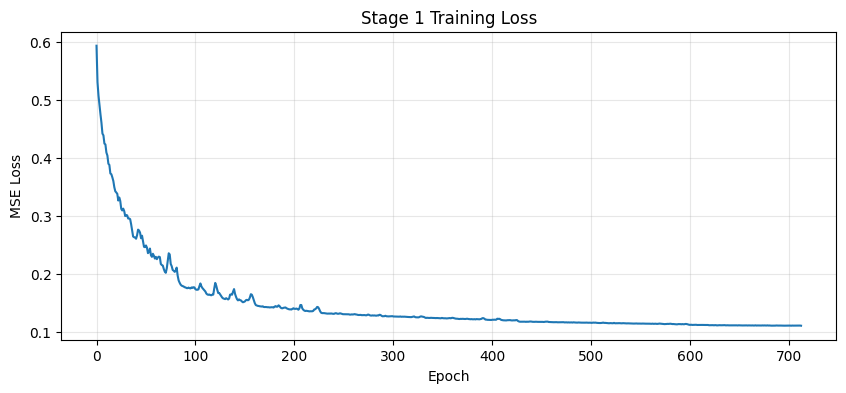

In [16]:
# Plot training process
plt.figure(figsize=(10, 4))
plt.plot(lossgraph_stage1)
plt.title('Stage 1 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

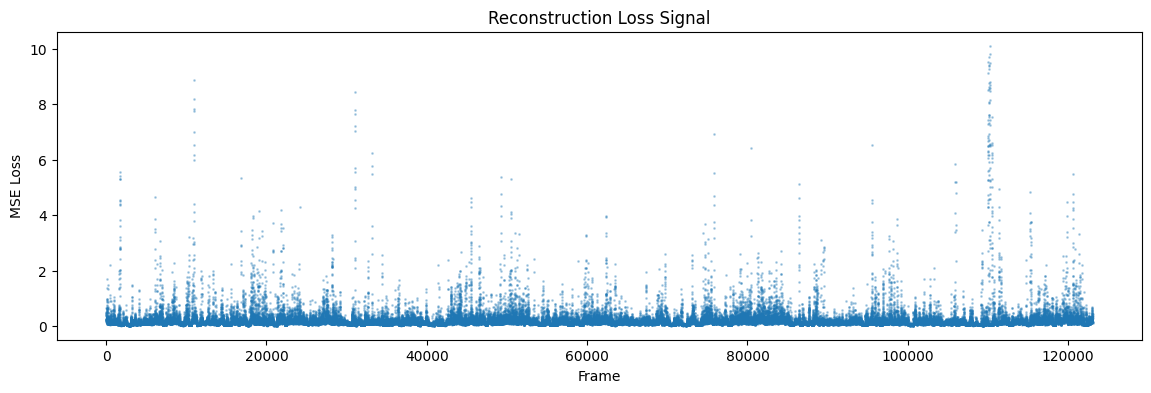

In [17]:
# Plot loss signal
plt.figure(figsize=(14, 4))
plt.plot(positions, losses, '.', markersize=2, alpha=0.3)
plt.title('Reconstruction Loss Signal')
plt.xlabel('Frame')
plt.ylabel('MSE Loss')
plt.show()

Bayesian search for optimal percentile and quantile 

In [18]:
# ── Define search space ──────────────────────────────────────
search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE,   name='quantile'),
    #Real(*LR_RANGE,         name='lr', prior='log-uniform'),
]

search_log = []
best_results = None
best_score = -1
iteration = 0

In [19]:
# ── Objective function ───────────────────────────────────────
@use_named_args(search_space)
def objective(percentile, quantile, lr=LR):
    global iteration, best_score, best_results

    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration}/{MAX_ITER}  |  percentile={percentile:.2f}, quantile={quantile:.4f}, lr={lr:.6f}")
    print(f"{'='*60}")

    # Stage 3: transitions
    transition_frames, smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=25
    )

    # Stage 4: variable windows
    windows, window_segment_labels = create_windows_from_transitions(
        raw_processed, transition_frames,
        min_segment_frames=5, max_segment_frames=60
    )
    
    if len(windows) < 10:
        print(f"  too few windows ({len(windows)}) — skipping")
        return 0.0

    # Stage 4b: retrain on variable windows (with tuned lr)
    model_file_name = "model_stage2_"+str(iteration)+".pth"
    if Path(model_file_name).is_file():
        n_joints  = raw_processed.shape[1]
        joint_dim = raw_processed.shape[2]

        model_stage2 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
        state_dict = torch.load(model_file_name, weights_only=True)
        model_stage2.load_state_dict(state_dict)
        print("model_satge2 loaded...")
    else:
        model_stage2, lossgraph_stage2 = train_on_variable_windows(
            raw_processed, windows, epochs=VW_EPOCHS, lr=lr, device=device
        )
        torch.save(model_stage2.state_dict(), os.path.join('./', model_file_name))

    # Stage 5: encode + cluster
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows, quantile=quantile,
        umap_neighbors=15, umap_min_dist=0.1, device=device
    )

    n_clusters = len(np.unique(cluster_labels))

    # ── Compute silhouette score ──────────────────────────────
    # silhouette needs at least 2 clusters and more samples than clusters
    if n_clusters < 2 or n_clusters >= len(latents_2d):
        print(f"  → {n_clusters} clusters — skipping silhouette (invalid cluster count)")
        score = -1.0
    else:
        score = silhouette_score(latents_2d, cluster_labels)

    log_entry = {
        "iteration": iteration,
        "percentile": round(percentile, 2),
        "quantile": round(quantile, 4),
        "lr": round(float(lr), 6),
        "n_clusters": n_clusters,
        "silhouette": round(float(score), 4),
    }
    search_log.append(log_entry)
    print(f"  → {n_clusters} clusters, silhouette={score:.4f}")

    # Track best
    if score > best_score:
        best_score = score
        best_results = {
            'model': model_stage2,
            'model_stage1': model_stage1,
            'latents': latents,
            'latents_2d': latents_2d,
            'cluster_labels': cluster_labels,
            'transition_frames': transition_frames,
            'windows': windows,
            'window_segment_labels': window_segment_labels,
            'losses': losses,
            'positions': positions,
            'lossgraph_stage1': lossgraph_stage1,
            'lossgraph_stage2': lossgraph_stage2,
            'smoothed_losses': smoothed,
            '_percentile': percentile,
            '_quantile': quantile,
            '_lr': lr,
        }
        print(f"  ** NEW BEST (silhouette={score:.4f}) **")

    # Cleanup GPU memory
    del model_stage2, latents, latents_2d, cluster_labels, ms_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # gp_minimize minimizes, so return negative score
    return -score

In [20]:
# ── Run Bayesian optimization ────────────────────────────────
bayes_result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=MAX_ITER,
    n_initial_points=min(MAX_ITER, 5),
    random_state=42,
    verbose=False,
)


ITERATION 1/15  |  percentile=73.90, quantile=0.1367, lr=0.001000
Found 3702 transitions
Mean bout duration: 1.33s
Bout duration looks plausible
Created 4629 variable-length windows from 3703 segments
Window lengths — min: 6, max: 60, mean: 26.5
Retraining on variable-length windows...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/1000 — Loss: 0.709908  patience: 0/30
Epoch 20/1000 — Loss: 0.578218  patience: 0/30
Epoch 30/1000 — Loss: 0.490542  patience: 0/30
Epoch 40/1000 — Loss: 0.444119  patience: 1/30
Epoch 50/1000 — Loss: 0.405436  patience: 0/30
Epoch 60/1000 — Loss: 0.397105  patience: 1/30
Epoch 70/1000 — Loss: 0.372993  patience: 0/30
Epoch 80/1000 — Loss: 0.356244  patience: 0/30
Epoch 90/1000 — Loss: 0.342372  patience: 1/30
Epoch 100/1000 — Loss: 0.335922  patience: 2/30
Epoch 110/1000 — Loss: 0.325759  patience: 0/30
Epoch 120/1000 — Loss: 0.326326  patience: 6/30
Epoch 130/1000 — Loss: 0.277876  patience: 0/30
Epoch 140/1000 — Loss: 0.279107  patience: 3/30
Epoch 150/1000 — Loss: 0.271474  patience: 1/30
Epoch 160/1000 — Loss: 0.264639  patience: 0/30
Epoch 170/1000 — Loss: 0.260034  patience: 2/30
Epoch 180/1000 — Loss: 0.259413  patience: 7/30
Epoch 190/1000 — Loss: 0.252778  patience: 3/30
Epoch 200/1000 — Loss: 0.251482  patience: 9/30
Epoch 210/1000 — Loss: 0.233082  patience: 2/30
E

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (4629, 2)
Estimated bandwidth: 0.1629
Found 5 clusters
Cluster sizes: [3078  666  512  324   49]
Silhouette score: 0.8039
  → 5 clusters, silhouette=0.3170
  ** NEW BEST (silhouette=0.3170) **

ITERATION 2/15  |  percentile=73.39, quantile=0.2194, lr=0.001000
Found 3771 transitions
Mean bout duration: 1.31s
Bout duration looks plausible
Created 4680 variable-length windows from 3772 segments
Window lengths — min: 6, max: 60, mean: 26.3
Retraining on variable-length windows...


...

UMAP done. Shape: (5576, 2)
Estimated bandwidth: 0.2701
Found 8 clusters
Cluster sizes: [4167  483  488  342   33   25   22   16]
Silhouette score: 0.8299
  → 8 clusters, silhouette=0.4578

ITERATION 15/15  |  percentile=63.60, quantile=0.1519, lr=0.001000
Found 4869 transitions
Mean bout duration: 1.01s
Bout duration looks plausible
Created 5567 variable-length windows from 4870 segments
Window lengths — min: 6, max: 60, mean: 22.1
Retraining on variable-length windows...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/1000 — Loss: 0.633863  patience: 0/30
Epoch 20/1000 — Loss: 0.485767  patience: 0/30
Epoch 30/1000 — Loss: 0.421554  patience: 0/30
Epoch 40/1000 — Loss: 0.384209  patience: 4/30
Epoch 50/1000 — Loss: 0.357977  patience: 4/30
Epoch 60/1000 — Loss: 0.333211  patience: 0/30
Epoch 70/1000 — Loss: 0.328435  patience: 0/30
Epoch 80/1000 — Loss: 0.311254  patience: 1/30
Epoch 90/1000 — Loss: 0.290785  patience: 0/30
Epoch 100/1000 — Loss: 0.313511  patience: 10/30
Epoch 110/1000 — Loss: 0.261357  patience: 2/30
Epoch 120/1000 — Loss: 0.251710  patience: 0/30
Epoch 130/1000 — Loss: 0.251610  patience: 3/30
Epoch 140/1000 — Loss: 0.245034  patience: 2/30
Epoch 150/1000 — Loss: 0.239088  patience: 0/30
Epoch 160/1000 — Loss: 0.234958  patience: 0/30
Epoch 170/1000 — Loss: 0.233643  patience: 4/30
Epoch 180/1000 — Loss: 0.215491  patience: 0/30
Epoch 190/1000 — Loss: 0.213276  patience: 5/30
Epoch 200/1000 — Loss: 0.210633  patience: 2/30
Epoch 210/1000 — Loss: 0.207853  patience: 0/30


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (5567, 2)
Estimated bandwidth: 0.1177
Found 4 clusters
Cluster sizes: [2181 1641 1016  729]
Silhouette score: 0.7750
  → 4 clusters, silhouette=0.4356


In [21]:
# ── Summary ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print("HYPERPARAMETER SEARCH COMPLETE")
print(f"{'='*60}")
print(f"\nSearch log:")
for entry in search_log:
    marker = " <-- BEST" if entry['silhouette'] == best_score else ""
    print(f"  Iter {entry['iteration']:2d}: percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, silhouette={entry['silhouette']:.4f}{marker}")

print(f"\nBest result:")
print(f"  percentile : {best_results['_percentile']:.2f}")
print(f"  quantile   : {best_results['_quantile']:.4f}")
print(f"  lr         : {best_results['_lr']:.6f}")
print(f"  clusters   : {len(np.unique(best_results['cluster_labels']))}")
print(f"  silhouette : {best_score:.4f}")

# Set results to best for downstream cells
results = best_results

# Save the model
torch.save(results['model'].state_dict(), os.path.join('./', "model_stage2.pth"))

with open("lossgraph_stage2.json", "w") as file:
    json.dump(results['lossgraph_stage2'], file)


HYPERPARAMETER SEARCH COMPLETE

Search log:
  Iter  1: percentile=73.90, quantile=0.1367, lr=0.001000  →  5 clusters, silhouette=0.3170
  Iter  2: percentile=73.39, quantile=0.2194, lr=0.001000  →  3 clusters, silhouette=0.3614
  Iter  3: percentile=63.37, quantile=0.1200, lr=0.001000  →  6 clusters, silhouette=0.3040
  Iter  4: percentile=63.78, quantile=0.1667, lr=0.001000  →  3 clusters, silhouette=0.5460
  Iter  5: percentile=54.29, quantile=0.2302, lr=0.001000  →  3 clusters, silhouette=0.4256
  Iter  6: percentile=64.72, quantile=0.1705, lr=0.001000  →  4 clusters, silhouette=0.2206
  Iter  7: percentile=63.76, quantile=0.1661, lr=0.001000  →  4 clusters, silhouette=0.3419
  Iter  8: percentile=63.88, quantile=0.1695, lr=0.001000  →  3 clusters, silhouette=0.5162
  Iter  9: percentile=63.87, quantile=0.1803, lr=0.001000  →  4 clusters, silhouette=0.3631
  Iter 10: percentile=64.01, quantile=0.1708, lr=0.001000  →  5 clusters, silhouette=0.2603
  Iter 11: percentile=63.78, quanti

Plot cluster 

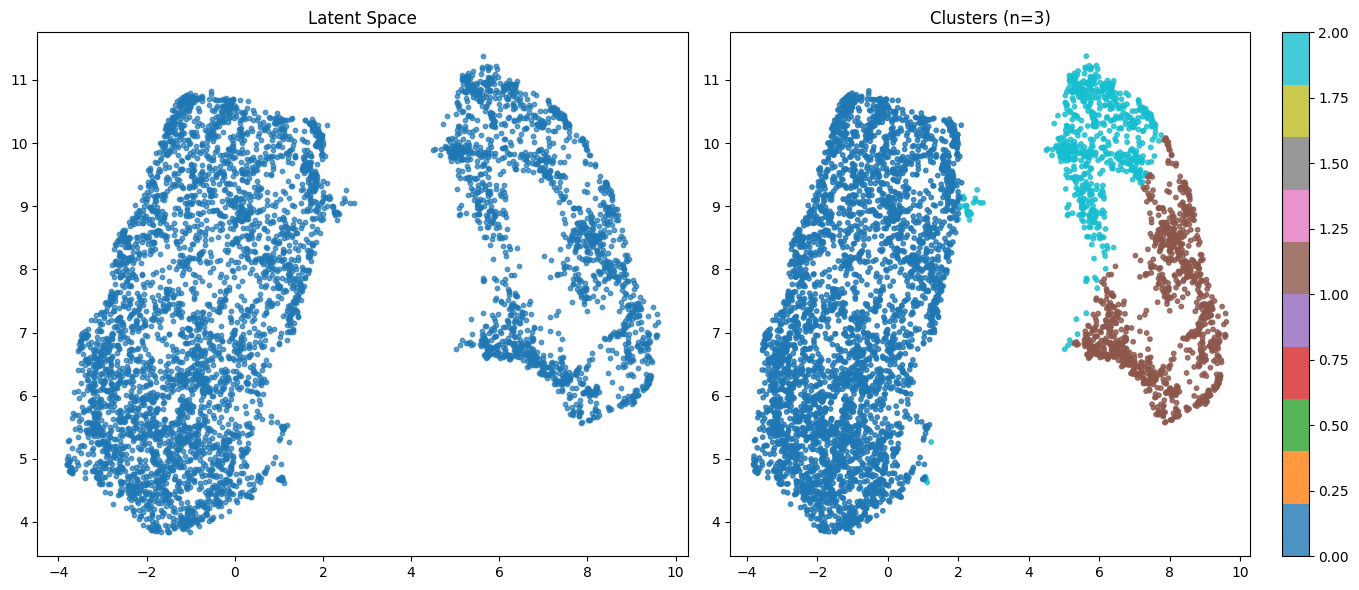

In [22]:
latents_2d     = results['latents_2d']
cluster_labels = results['cluster_labels']
n_clusters     = len(np.unique(cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], s=10, alpha=0.7)
axes[0].set_title('Latent Space')
sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                     c=cluster_labels, cmap='tab10', s=10, alpha=0.8)
axes[1].set_title(f'Clusters (n={n_clusters})')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

Reconstruct window

Window starts: 5555 vs windows: 5555
PD windows: 2977, Control windows: 2578


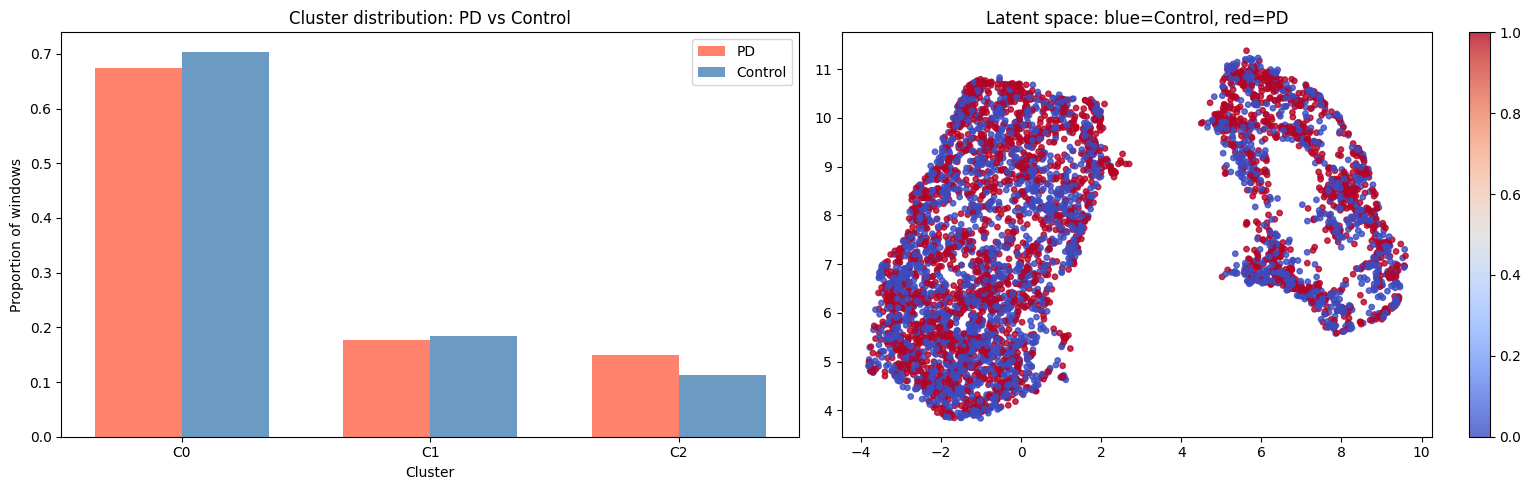


Cluster          PD    Control   Ratio PD/C
  C0          0.674      0.704         0.96
  C1          0.177      0.183         0.96
  C2          0.149      0.112         1.33


In [23]:
min_segment_frames = 5
max_segment_frames = 60
boundaries = np.unique(
    np.concatenate([[0], results['transition_frames'], [len(raw_processed)]])
).astype(int)

starts = []
for seg_idx in range(len(boundaries) - 1):
    seg_start = boundaries[seg_idx]
    seg_end   = boundaries[seg_idx + 1]
    seg_len   = seg_end - seg_start
    if seg_len < min_segment_frames: continue
    for chunk_start in range(0, seg_len, max_segment_frames):
        abs_start = seg_start + chunk_start
        abs_end   = min(abs_start + max_segment_frames, seg_end)
        if (abs_end - abs_start) < min_segment_frames: continue
        starts.append(abs_start)
starts = np.array(starts)
print(f"Window starts: {len(starts)} vs windows: {len(results['windows'])}")

# assign PD/C label to each window
window_group_labels = []
for win_idx in range(len(results['windows'])):
    abs_start    = starts[win_idx]
    abs_end      = abs_start + len(results['windows'][win_idx])
    frame_labels = group_labels_arr[abs_start:abs_end]
    majority     = int(np.round(frame_labels.mean()))
    window_group_labels.append(majority)

window_group_labels = np.array(window_group_labels)
pd_mask = window_group_labels == 1
c_mask  = window_group_labels == 0
print(f"PD windows: {pd_mask.sum()}, Control windows: {c_mask.sum()}")

cluster_labels = results['cluster_labels']
n_clusters     = len(np.unique(cluster_labels))
pd_counts = np.array([(cluster_labels[pd_mask] == c).sum() for c in range(n_clusters)])
c_counts  = np.array([(cluster_labels[c_mask]  == c).sum() for c in range(n_clusters)])
pd_props  = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else pd_counts
c_props   = c_counts  / c_counts.sum()  if c_counts.sum()  > 0 else c_counts

x = np.arange(n_clusters)
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(x - w/2, pd_props, w, label='PD',      color='tomato',    alpha=0.8)
axes[0].bar(x + w/2, c_props,  w, label='Control', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Proportion of windows')
axes[0].set_title('Cluster distribution: PD vs Control')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'C{i}' for i in range(n_clusters)])
axes[0].legend()

sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                     c=window_group_labels, cmap='coolwarm',
                     s=15, alpha=0.8, vmin=0, vmax=1)
axes[1].set_title('Latent space: blue=Control, red=PD')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"\n{'Cluster':<10} {'PD':>8} {'Control':>10} {'Ratio PD/C':>12}")
for i in range(n_clusters):
    ratio = pd_props[i] / c_props[i] if c_props[i] > 0 else float('inf')
    print(f"  C{i:<7} {pd_props[i]:>8.3f} {c_props[i]:>10.3f} {ratio:>12.2f}")

In [24]:
with open("best_results.pkl", "wb") as file:
    pickle.dump(results, file)

Load best_results from local disk

In [ ]:
with open("best_results.pkl", "rb") as file:
    results = pickle.load(file)